In [1]:
# Task 1 -Dataset Collection
import kagglehub
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Asus\.cache\kagglehub\datasets\asdasdasasdas\garbage-classification\versions\2


In [4]:
import os

os.listdir(path)

['Garbage classification',
 'one-indexed-files-notrash_test.txt',
 'one-indexed-files-notrash_train.txt',
 'one-indexed-files-notrash_val.txt',
 'one-indexed-files.txt',
 'zero-indexed-files.txt']

Dataset downloaded at: C:\Users\Asus\.cache\kagglehub\datasets\asdasdasasdas\garbage-classification\versions\2
Dataset classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Data preprocessing pipeline created successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.2208 - loss: 1.8680 - val_accuracy: 0.2346 - val_loss: 1.6661
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.2950 - loss: 1.6077 - val_accuracy: 0.3877 - val_loss: 1.5210
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.3794 - loss: 1.5046 - val_accuracy: 0.3260 - val_loss: 1.6141
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3992 - loss: 1.4259 - val_accuracy: 0.3161 - val_loss: 1.6519
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.4101 - loss: 1.4399 - val_accuracy: 0.4235 - val_loss: 1.4442
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.4536 - loss: 1.3604 - val_accuracy: 0.4314 - val_loss: 1.4133
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.4541 - loss: 1.3625 - val_accuracy: 0.4513 - val_loss: 1.3935
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.4847 - loss: 1.3109 - val_accuracy: 0.4553 - val_loss

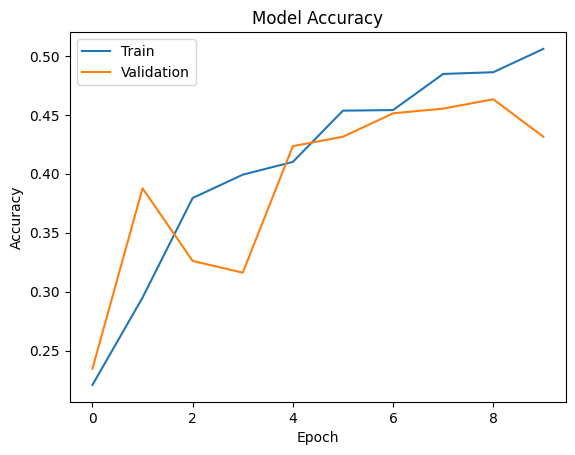

Model saved successfully!
Place a test image named 'test.jpg' in the project folder to test prediction.


In [5]:
# Task2  – Data Preprocessing

import kagglehub
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

path = kagglehub.dataset_download("asdasdasasdas/garbage-classification")

print("Dataset downloaded at:", path)

# Dataset folder
dataset_path = os.path.join(path, "Garbage classification", "Garbage classification")
print("Dataset classes:", os.listdir(dataset_path))

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    shear_range=0.2,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Data preprocessing pipeline created successfully!")

# Task3 - CNN Model Development
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(6,activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()

model.save("garbage_classifier_model.h5")

print("Model saved successfully!")

img_path = "test.jpg"

if os.path.exists(img_path):

    img = image.load_img(img_path,target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array,axis=0)
    img_array = img_array/255.0

    prediction = model.predict(img_array)

    classes = list(train_generator.class_indices.keys())

    print("Predicted class:", classes[np.argmax(prediction)])

else:
    print("Place a test image named 'test.jpg' in the project folder to test prediction.")

16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 441ms/step
Predictions generated successfully!

Model Accuracy: 0.1988071570576541


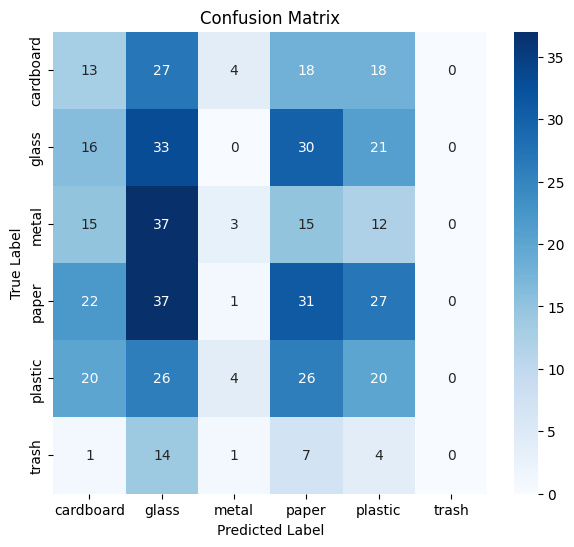


Sample Test Predictions:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step


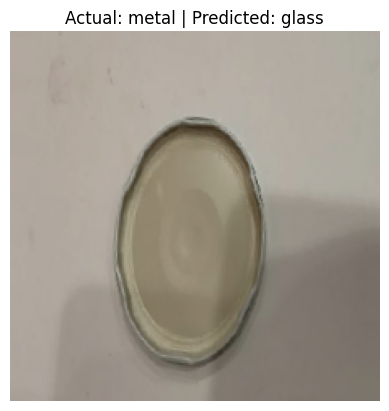

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


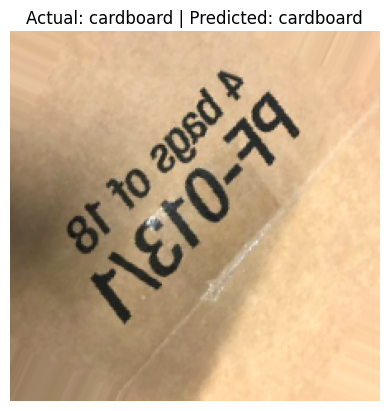

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


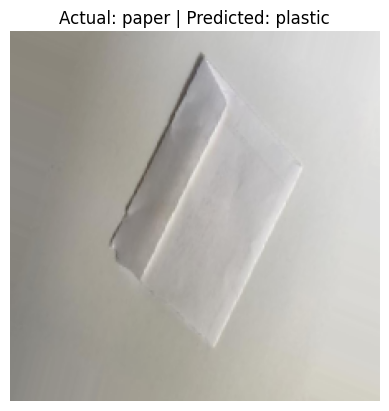

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


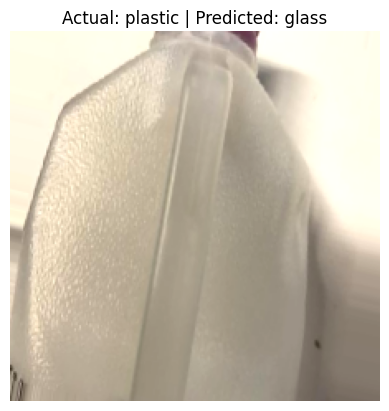

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


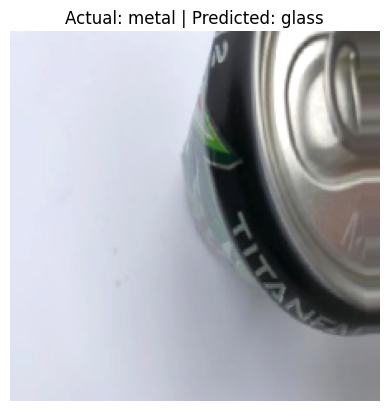

In [11]:
# ===============================
# Task 4 – Model Evaluation
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Reset generator before prediction
validation_generator.reset()

# Get predictions
predictions = model.predict(validation_generator)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_classes = validation_generator.classes

# Class names
class_names = list(validation_generator.class_indices.keys())

print("Predictions generated successfully!")


accuracy = accuracy_score(true_classes, predicted_classes)
print("\nModel Accuracy:", accuracy)


cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

print("\nSample Test Predictions:\n")

images, labels = next(validation_generator)

for i in range(5):

    img = images[i]
    actual_label = class_names[np.argmax(labels[i])]

    img_array = np.expand_dims(img, axis=0)

    prediction = model.predict(img_array)
    predicted_label = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.title(f"Actual: {actual_label} | Predicted: {predicted_label}")
    plt.axis("off")
    plt.show()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 895ms/step - accuracy: 0.5815 - loss: 1.1454 - val_accuracy: 0.6879 - val_loss: 0.8396
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 859ms/step - accuracy: 0.7144 - loss: 0.7666 - val_accuracy: 0.6899 - val_loss: 0.7269
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 866ms/step - accuracy: 0.7762 - loss: 0.6351 - val_accuracy: 0.7256 - val_loss: 0.6959
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 58s 906ms/step - accuracy: 0.7969 - loss: 0.5633 - val_accuracy: 0.7515 - val_loss: 0.6721
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8048 - loss: 0.5330 - val_accuracy: 0.7515 - val_loss: 0.6674
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 996ms/step - accuracy: 0.8335 - loss: 0.4641 - val_accuracy: 0.7495 - val_loss: 0.6452
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8315 - loss: 0.4474 - val_accuracy: 0.7038 - val_loss: 0.7585
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 964ms/step - accuracy: 0.8375 - loss: 0.4473 - val_accuracy: 

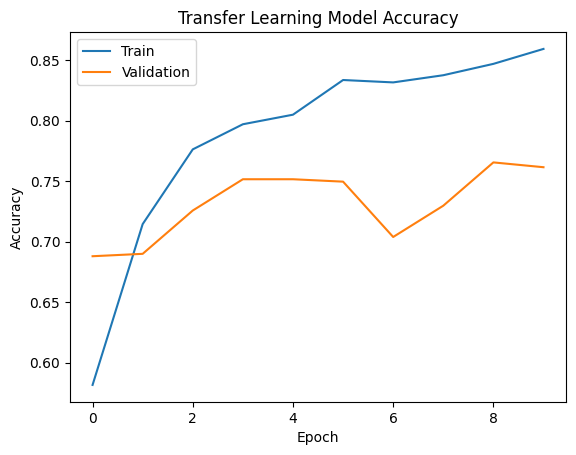

In [12]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)


for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# IMPORTANT → dataset has 6 classes
predictions = Dense(6, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)


transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

history_transfer = transfer_model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])

plt.title("Transfer Learning Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()